# Subsampling MCMC --- An approach to speed up MCMC by data subsampling
## Computer Lab: Approximate subsampling MCMC with parameter expanded Taylor control variates

This computer lab is covered over two tutorials. Tutorial 1 covers the Metropolis-Hastings algorithm and includes Sections 2 and 3. Tutorial 2 covers the approximate subsampling MCMC algorithm and includes Sections 4 and 5. During the tutorial sessions, I will demonstrate and explain the code that I have provided below. I will then give you some time to try the exercises on your own. At the end of each tutorial session, I will demonstrate how to solve the exercises. The solutions will be uploaded to the Slack channel after each tutorial.

The computer lab is outlined as follows. We consider two regression models with, respectively, a Poisson and von Mises response variable. I have provided most of the code for the Poisson model and it is your task to write the corresponding code for the von Mises regression using the hints given. You will also be given tasks that include writing code for the Poisson example.

**Important notes**: 
1. <span style="color:red">**You are only supposed to write your own code when you are doing an exercise, which will be highlighted with the text by Exercise X.Y.Z.** </span>  
2. The code provided in the cells is not supposed to be edited (unless copied to another cell). <span style="color:red">**Feel free to play around with the provided code, but note that the rest of the sections might not compile if you cause an error.** </span>
3. Use the help() function (or Google) to find out how a function works.
4. For debugging purposes, it is sometimes useful to clean all variables. You can use the restart kernel approach in Jupyter notebook (see the instructions). Do not forget to rerun the relevant cells afterwards.



## 1. Modules 
The computer lab itself starts in Section 2. This section will install and import modules, and define some auxiliary functions that will be useful. 
### 1.1 Install modules
Run the two cells below to install these packages if you do not have them already. You may have to restart the kernel to use the updated packages.

In [18]:
pip install autograd

You should consider upgrading via the '/Users/thangtm589/Desktop/study/UTS/35112 Mathematical Research/winston-uts-research/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [19]:
pip install pymc3

You should consider upgrading via the '/Users/thangtm589/Desktop/study/UTS/35112 Mathematical Research/winston-uts-research/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


### 1.2 Import modules
Run the cell below to import the relevant modules and functions for this lab.

In [20]:
# Import modules
import matplotlib, time, copy
import matplotlib.pyplot as plt
import autograd.numpy as np
import autograd.scipy.stats as sps_autograd
from autograd import grad, hessian
from autograd.scipy.special import i0 as i0_autograd
import scipy.stats as sps
from scipy.optimize import minimize
from pymc3 import ess as effective_sample_size
from scipy.special import gammaln
import statsmodels.api as sm

### 1.3 Auxiliary functions

In [21]:
# Source: https://github.com/statsmodels/statsmodels/blob/main/statsmodels/sandbox/distributions/multivariate.py#L90
# Function written by Enzo Michelangeli, style changes by josef-pktd
# Student's T random variable
def multivariate_t_rvs(m, S, df = np.inf, n=1):
    '''generate random variables of multivariate t distribution
    Parameters
    ----------
    m : array_like
        mean of random variable, length determines dimension of random variable
    S : array_like
        square array of covariance  matrix
    df : int or float
        degrees of freedom
    n : int
        number of observations, return random array will be (n, len(m))
    Returns
    -------
    rvs : ndarray, (n, len(m))
        each row is an independent draw of a multivariate t distributed
        random variable
    '''
    m = np.asarray(m)
    d = len(m)
    if df == np.inf:
        x = 1.
    else:
        x = np.random.chisquare(df, n)/df
    z = np.random.multivariate_normal(np.zeros(d),S,(n,))
    return m + z/np.sqrt(x)[:,None]   # same output format as random.multivariate_normal

# Source: https://gregorygundersen.com/blog/2020/01/20/multivariate-t/
# Comments added by Matias Quiroz
def multivariate_t_logpdf(x, mean, shape, df):
    """
    Computes the log-density of a multivariate Student-t vector x with location mean and scale matrix shape,
    with degrees of freedom df.
    """
    dim = mean.size

    vals, vecs = np.linalg.eigh(shape)
    logdet     = np.log(vals).sum()
    valsinv    = np.array([1./v for v in vals])
    U          = vecs * np.sqrt(valsinv)
    dev        = x - mean
    maha       = np.square(np.dot(dev, U)).sum(axis=-1)

    t = 0.5 * (df + dim)
    A = gammaln(t)
    B = gammaln(0.5 * df)
    C = dim/2. * np.log(df * np.pi)
    D = 0.5 * logdet
    E = -t * np.log(1 + (1./df) * maha)

    return A - B - C - D + E

## 2. Models and data
### 2.1 Example models
We consider the following two regression models.
#### 2.1.1 Model 1: Poisson regression model for count data
The Poisson regression model is useful for modeling the probability distribution of count data $y\in \mathbb{Z}_{\geq 0}$ as a function of a set of explanatory variables $\boldsymbol{x}\in \mathbb{R}^d$. One possible application is modeling the number of hospital visits of an individual as a function of variables such as age, distance to closest hospital, socio-economic variables, etc. 

We consider the model 
\begin{align*}
 y_{k} & \sim & \mathrm{Poisson}\left(\exp\left(\boldsymbol{\beta}^\top\boldsymbol{x}_k\right)\right), k = 1,\dots, n,\\
 \boldsymbol{\beta} & \sim & \mathcal{N}(\boldsymbol{0}, 10^2\boldsymbol{I}).
\end{align*}
With $\boldsymbol{\theta} = \boldsymbol{\beta}$, the density of a single observation is
\begin{align*}
 p(y_{k}|\boldsymbol{\theta}) & = &  \frac{\exp\left(y_k\boldsymbol{\theta}^\top\boldsymbol{x}_k\right)\exp\left(-\exp\left(\boldsymbol{\theta}^\top\boldsymbol{x}_k\right)\right)}{y_k!},
\end{align*}
and
\begin{align*}
 \ell_k(\boldsymbol{\theta})= \log p(y_{k}|\boldsymbol{\theta}) & = &  y_k \boldsymbol{\theta}^\top\boldsymbol{x}_k -\exp\left(\boldsymbol{\theta}^\top\boldsymbol{x}_k\right) - \log(y_k!).
\end{align*}
The following code implements the log-density. 

In [22]:
def log_density_Poisson(theta, y, X):
    """
    Computes the log-density of the Poisson model evaluated at theta for each of the observations in y, X.
    """
    beta = theta
    return sps_autograd.poisson.logpmf(y, np.exp(np.dot(X, beta)))

#### 2.1.2 Model 2: von Mises regression model for angular data
The von Mises probability distribution is useful for modeling angular/directional data. Its density function is given by
$$f(y| \mu, \kappa) = \frac{\exp\left(\kappa \cos(y - \mu)\right)}{2\pi I_0(\kappa)}, \quad -\pi < y < \pi,$$
where $\mu \in (-\pi, \pi)$ is the mean direction, $\kappa$ is a measure of concentration around $\mu$, and $I_0$ is the modified Bessel function of order $0$. A regression extension of this model is achieved by modeling the mean direction $\mu$ as a function of covariates. We assume that $\kappa$ does not depend on covariates for simplicity, but this extension is possible$^1$. One possible application of our regression model is modeling the wind direction at a location as a function of atmospherical variables.

We consider the model
\begin{eqnarray*}
 y_{k} & \sim & \mathrm{von Mises}\left(\mu_k, \kappa\right), k = 1,\dots, n,\\
 \mu_k & = & 2\arctan\left(\boldsymbol{\beta}^\top\boldsymbol{x}_k\right) \\
 \boldsymbol{\beta} & \sim & \mathcal{N}(\boldsymbol{0}, 10^2\boldsymbol{I}) \\
 \log \kappa & \sim & \mathcal{N}(0, 10^2)
 .
\end{eqnarray*}
With $\boldsymbol{\theta} = (\boldsymbol{\beta}, \log \kappa)^\top$, the density of a single observation is
\begin{eqnarray*}
 p(y_{k}|\boldsymbol{\theta}) & = &  \frac{\exp\left(\kappa \cos\left(y_k - 2\arctan\left(\boldsymbol{\beta}^\top\boldsymbol{x}_k\right)\right)\right)}{2\pi I_0(\kappa)},
\end{eqnarray*}
and
\begin{eqnarray*}
 \ell_k(\boldsymbol{\theta})= \log p(y_{k}|\boldsymbol{\theta}) & = & \kappa \cos\left(y_k - 2\arctan\left(\boldsymbol{\beta}^\top\boldsymbol{x}_k\right)\right) - \log(2\pi) - \log I_0(\kappa).
\end{eqnarray*}

$\textbf{Exercise 2.1.2}$: Implement the log-density of the model. Provide the required code in the cell below.

**Hint**: The modified Bessel function of order $0$ is implemented in autograd and accessed via the imported *i0_autograd* function.

<sub>$^1$: Fisher, N. I., and Lee, A. J. (1992). Regression models for an angular response. *Biometrics*, 665-677.

In [23]:
def log_density_von_Mises(theta, y, X):
    """
    Computes the log-density of the von Mises model evaluated at theta = (beta, log-kappa) for each of 
    the observations in y, X.
    """
    beta = theta[:-1]
    mu = 2*np.arctan(np.dot(X, beta))
    kappa = np.exp(theta[-1])
    
    return kappa*np.cos(y - mu) - np.log(2*np.pi) - np.log(i0_autograd(kappa))

### 2.2 Example data
Since I do not have access to large real world datasets for the models above, we will use simulated data in this computer lab. It is always good practice to start with simulated data, as we know the true parameter values and can check if our algorithms can recover them. 

#### 2.2.1 Poisson regression data
The simulation setting uses $d=10$ parameters, with the true parameter vector being
$$\boldsymbol{\theta}_0 = (4.30, 1.60, -1.06,  0.77,  2.37, -0.14, -0.81, -0.67,  0.45, -0.98)^\top.$$
The first effect corresponds to an intercept (so that the corresponding covariate is $x=1$). The covariates $x$ (excluding the intercept) should be correlated to more resemble real data. We can achieve this by simulating them from a $\mathcal{N}\left(\boldsymbol{0}, \boldsymbol{\widetilde{\Sigma}}\right)$ distribution, where $\boldsymbol{\widetilde{\Sigma}} \sim \mathrm{Wishart}(I, \nu)$ with $I$ being the (9 dimensional) identity matrix and $\nu  = 11$ degrees of freedom. We rescale the resulting $X$ to ensure values of $y$ are not too large.

The following code implements a simulation from the Poisson regression model following the instructions above.

In [24]:
# Code to simulate data for the Poisson regression model
def simulate_Poisson_data(n):
    np.random.seed(10)    
    beta0 = np.array([4.30, 1.60, -1.06,  0.77,  2.37, -0.14, -0.81, -0.67,  0.45, 0.98])
    Sigma_tilde = sps.wishart.rvs(df = 9, scale = np.eye(9), size = 1)
    X = np.random.multivariate_normal(np.zeros(9), Sigma_tilde, size = n)
    X = np.sqrt(0.1)*(X - np.mean(X))/np.sqrt(np.var(X, axis = 0))
    X = np.hstack((np.ones((n, 1)), X)) # add intercept
    y = sps.poisson.rvs(np.exp(np.dot(X, beta0))) 
    theta0 = beta0
    return((y, X, theta0))

n = 10000
y, X, theta0 = simulate_Poisson_data(n)
print(theta0)
d = len(theta0) # dimension of parameter vector. 


[ 4.3   1.6  -1.06  0.77  2.37 -0.14 -0.81 -0.67  0.45  0.98]


#### 2.2.2 Von Mises regression data
The simulation setting uses $d=10$ parameters, with the true parameter vector being
$$\boldsymbol{\theta}_0 = (1.75,  0.96, -1.3, 0.52, 0.64, -1.01, -1.22, 0.61, 0.1, \log(0.4))^\top.$$
The first effect corresponds to an intercept (so that the corresponding covariate is $x=1$). We simulate the covariates similar to the Poisson regression case (see the code below).

$\textbf{Exercise 2.2.2}$: Complete the function in the code below that simulates from the von Mises regression model following the instructions above.

**Hint**: *np.random.vonmises* is a numpy function that simulates from the von Mises distribution.

In [25]:
def simulate_von_Mises_data(n):
    np.random.seed(10)    
    beta0 = np.array([ 1.75,  0.96, -1.3, 0.52, 0.64, -1.01, -1.22, 0.61, 0.1])
    kappa0 = 0.4
    Sigma_tilde = sps.wishart.rvs(df = 9, scale = np.eye(8), size = 1)
    X = np.random.multivariate_normal(np.zeros(8), Sigma_tilde, size = n)
    X = (X - np.mean(X))/np.sqrt(np.var(X, axis = 0))
    X = np.hstack((np.ones((n, 1)), X)) # add intercept
    # Simulate y given the parameters and covariate above.
    y = np.random.vonmises(mu = 2*np.arctan(np.dot(X, beta0)), kappa = kappa0)
    theta0 = np.hstack((beta0, np.log(kappa0)))
    return((y, X, theta0))

n = 100000
y, X, theta0 = simulate_von_Mises_data(n)
d = len(theta0) # dimension of parameter vector. 

### 2.3 Optimisation
We now perform optimisation to find the maximum likelihood estimate (MLE). It is a good practice to check that the MLE recovers the true parameters (within the confidence interval). This ensures that the log-density is correctly coded. 

To carry out this task efficiently, the gradient and Hessian of the log-likelihood are useful. We can use automatic differentiation to compute these quantities, avoiding the need of deriving them by hand. In this computer lab, we will use autograd to perform automatic differentiation of the log-likelihood and the log-density. The latter is needed to construct the control variates of the subsampling algorithm in Section 4. For autograd to work, **we need to make sure that the mathematical functions we use are from the autograd package**. This is why we at the beginning of the worksheet used *'from autograd import numpy as np'* instead of the more common *'import numpy as np'*.

### 2.3.1 Maximum likelihood estimation of the Poisson regression model.
The following code maximises the log-likelihood and constructs confidence intervals for the Poisson regression model.

In [26]:
obj_func_likelihood = lambda param: -np.sum(log_density_Poisson(param, y, X)) # Maximise log-likelihood is the same
                                                                              # as minimize negative log-likelihood
grad_obj_func_likelihood = grad(obj_func_likelihood) # Gradient of obj_func_likelihood. Computed by automatic differentiation
Hess_obj_func_likelihood = hessian(obj_func_likelihood) # Hessian of obj_func_likelihood. Computed by automatic differentiation

# Optimise the log-likelihood to see if we recover true parameters
theta_optim_start = np.zeros(10)
res_optim_likelihood = minimize(obj_func_likelihood, theta_optim_start, method='BFGS', jac=grad_obj_func_likelihood, 
                                options={'gtol': 1e-04, 'maxiter': 1000, 'disp': True})

# Compare answers
print('True parameter values')
print(theta0)
print('MLE estimates')
MLE = res_optim_likelihood.x
print(np.round(MLE, 2))
print('95% Confidence intervals for MLE estimates')
Cov = np.linalg.inv(Hess_obj_func_likelihood(MLE)) # Negative Hessian inverse evaluated at the mode
print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2))
print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2))

ValueError: shapes (100000,9) and (10,) not aligned: 9 (dim 1) != 10 (dim 0)

### 2.3.2 Maximum likelihood estimation of the von Mises regression model.

$\textbf{Exercise 2.3.2}$: Find the maximum likelihood estimate and 95% confidence intervals of the von Mises regression model using your simulated data in Section 2.2.2. Can you recover the true parameter values? Provide the required code in the cell below.

**Hint**: The corresponding code for the Poisson model will be very useful.

In [ ]:
# Provide your code in this cell
obj_func_likelihood = lambda param: -np.sum(log_density_von_Mises(param, y, X)) # Maximise log-likelihood is the same
                                                                              # as minimize negative log-likelihood
grad_obj_func_likelihood = grad(obj_func_likelihood) # Gradient of obj_func_likelihood. Computed by automatic differentiation
Hess_obj_func_likelihood = hessian(obj_func_likelihood) # Hessian of obj_func_likelihood. Computed by automatic differentiation

# Optimise the log-likelihood to see if we recover true parameters
theta_optim_start = np.zeros(10)
res_optim_likelihood = minimize(obj_func_likelihood, theta_optim_start, method='BFGS', jac=grad_obj_func_likelihood, 
                                options={'gtol': 1e-04, 'maxiter': 1000, 'disp': True})

# Compare answers
print('True parameter values')
print(theta0)
print('MLE estimates')
MLE = res_optim_likelihood.x
print(np.round(MLE, 2))
print('95% Confidence intervals for MLE estimates')
Cov = np.linalg.inv(Hess_obj_func_likelihood(MLE)) # Negative Hessian inverse evaluated at the mode
print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2))
print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2))

Optimization terminated successfully.
         Current function value: 179843.473853
         Iterations: 26
         Function evaluations: 37
         Gradient evaluations: 37
True parameter values
[ 1.75        0.96       -1.3         0.52        0.64       -1.01
 -1.22        0.61        0.1        -0.91629073]
MLE estimates
[ 1.73  0.87 -1.26  0.62  0.65 -0.96 -1.16  0.62 -0.   -0.91]
95% Confidence intervals for MLE estimates
[ 1.67  0.68 -1.36  0.46  0.59 -1.06 -1.28  0.5  -0.17 -0.93]
[ 1.79  1.06 -1.16  0.77  0.72 -0.85 -1.04  0.74  0.17 -0.89]


## 3. The Metropolis-Hastings sampler
In this part of the worksheet, you will implement a Metropolis-Hastings sampler using the full data to sample from the posterior distribution. This will serve as the ground truth to compare your subsampling MCMC results against.

### 3.1 The log-likelihood and prior
The Metropolis-Hastings algorithm requires evaluation of the log-posterior (up to a proportionality constant), which is the log-likelihood plus the log-prior. Both models use a non-informative normal prior.

The following code implements the log-prior and log-likelihood. For the von Mises regression model, the latter assumes that you have coded the log-density in Section 2.1.2.

In [ ]:
def log_prior(theta):
    """
    Simple indepent normal prior with mean 0 and variance 10^2
    """
    return np.sum(sps_autograd.norm.logpdf(theta, 0, 10**2)) 

def log_likelihood(theta, y, X, model):
    """
    Log-likelihood for the model in the string model
    """
    if model == 'Poisson':
        return np.sum(log_density_Poisson(theta, y, X))
    elif model == 'von Mises':
        return np.sum(log_density_von_Mises(theta, y, X))
    else:
        raise NotImplementedError

### 3.2 The Metropolis-Hastings sampler
We now sample the posterior distribution using the Metropolis-Hastings sampler with a random walk proposal. For optimality of the random walk, we scale the proposal covariance by $\frac{2.38^2}{d}$, where $d$ is the number of parameters$^2$ .


<sub>$^2$: Gelman, A., Gilks, W. R., and Roberts, G. O. (1997). Weak convergence and optimal scaling of random walk Metropolis algorithms. *The Annals of Applied Probability*, 7(1):110-120.
    
#### 3.2.1 Poisson regression model
The following code implements the Metropolis-Hastings algorithm to sample from the posterior distribution of the Poisson regression model.

In [ ]:
# Specify model
model = 'Poisson'
# Define the log-posterior
log_posterior = lambda theta: log_likelihood(theta, y, X, model) + log_prior(theta) 
obj_func_posterior = lambda theta: -log_posterior(theta) # For maximisation purpose
grad_obj_func_posterior = grad(obj_func_posterior) # Gradient of obj_func_posterior. Computed by automatic differentiation
Hess_obj_func_posterior  = hessian(obj_func_posterior) # Hessian of obj_func_posterior. Computed by automatic differentiation

# Find starting values by optimising the log-posterior
theta_optim_start = np.zeros(10)
res_optim_posterior = minimize(obj_func_posterior, theta_optim_start, method='BFGS', jac=grad_obj_func_posterior, options={'gtol': 1e-04, 'maxiter': 1000, 'disp': True})

# Compare answers
print('True parameter values')
print(theta0)
print('MAP estimate')
MAP = res_optim_posterior.x
print(np.round(MAP, 2))
thetaStar_Poisson = MAP # Save for computing the control variate later
Sigma_pi_Poisson = np.linalg.inv(Hess_obj_func_posterior(MAP)) # Negative Hessian inverse evaluated at the mode
PropCov = 2.38**2/d*Sigma_pi_Poisson # Negative Hessian inverse evaluated at the mode

# Ready for Metropolis-Hastings sampling
N = 22000 # MCMC samples

# Storage
theta_init = MAP + sps.norm.rvs(0, 0.01, len(MAP))
samples = np.zeros((N + 1, d))
samples[0, :] = theta_init
log_p_samples = np.zeros(N + 1)
log_p_samples[0] = log_posterior(theta_init)
alphas = np.zeros(N)

# Current parameter and evaluate quantities
theta_c = theta_init      
log_post_c = log_posterior(theta_c)

tic = time.time()
print('MCMC with random walk proposal for the Poisson regression model with n = %s' % n)
for i in range(1, N + 1):

    if i % 1000 == 0:
        print("Iteration i = {}. Acceptance prob (mean) {:.2f}. Time: {:.2f}".format(i , np.mean(alphas[:i]), time.time() - tic))

    # Propose parameter and evaluate quantities
    theta_p = np.random.multivariate_normal(theta_c, PropCov, size = 1).flatten() # flatten() to get 1-dim array     
    log_post_p = log_posterior(theta_p)
    log_q_p = sps.multivariate_normal.logpdf(theta_p, mean = theta_c, cov = PropCov) # log-proposal density. Symmetric (cancels), but leave for completeness           
    log_q_c = sps.multivariate_normal.logpdf(theta_c, mean = theta_p, cov = PropCov)   
    
    alpha = np.min([1, np.exp(log_post_p - log_q_p - (log_post_c - log_q_c))])
    alphas[i - 1] = alpha
    if np.random.rand() < alpha: # sample Unif(0, 1) to determine acceptance
        samples[i, :] = theta_p
        log_p_samples[i] = log_post_p 
        # Proposed becomes current in next iteration
        theta_c, log_post_c, log_q_c = theta_p, log_post_p, log_q_p
    else:
        samples[i, :] = theta_c 
        log_p_samples[i] = log_post_c 
        

matplotlib.rc('text', usetex = True)
fig, ax = plt.subplots()
ax.plot(log_p_samples)
ax.set(xlabel='MCMC iteration', ylabel= r'$\log p(y|\theta)p(\theta)$' , 
       title= 'Log-posterior values over MCMC iterations')

# Use 2000 as burn-in
samples = samples[2000:] 
samples_Poisson_RW = samples # Save the samples from the random walk for future comparisons. 

# Effective sample size and inefficiency factors
ESS = np.zeros(samples.shape[1])
for j in range(samples.shape[1]):
    ESS[j] = effective_sample_size(samples[:, j])    
IF = samples.shape[0]/ESS
IF_MCMC_RW_Poisson = IF # Save for comparing to subsampling MCMC later

print("Mean ESS: {:.2f}. Median ESS: {:.2f}. Min ESS: {:.2f}. Max ESS: {:.2f}".format(np.mean(ESS), np.median(ESS), np.min(ESS), np.max(ESS)))
print("Mean IF : {:.2f}. Median IF : {:.2f}. Min IF : {:.2f}. Max IF : {:.2f}".format(np.mean(IF), np.median(IF), np.min(IF), np.max(IF)))

# KDE estimates for selected four parameters (0, 1, ... , d - 1)
params_to_plot = [0, 3, 8, 9]
assert(len(params_to_plot) == 4)
if model == 'Poisson':
    param_names = [r'$\beta_%s$' % item for item in range(d)]
elif model == 'von Mises':
    param_names = [r'$\beta_%s$' % item for item in range(d-1)] + [r'log$\kappa$']

fig, axs = plt.subplots(2, 2)
fig.suptitle('Kernel density estimates MCMC RW')
k = 0
for i in range(2):
    for j in range(2):
        min_x = np.min(samples[:, params_to_plot[k]])
        max_x = np.max(samples[:, params_to_plot[k]])
        x_grid = np.linspace(min_x, max_x, 500)
        kde = sm.nonparametric.KDEUnivariate(samples[:, params_to_plot[k]]) # kernel density for each parameter
        kde.fit() 
        axs[i, j].plot(kde.support, kde.density)
        axs[i, j].set_ylim(ymin = 0)
        axs[i, j].set(xlabel = param_names[params_to_plot[k]])
        k = k + 1
        
fig.tight_layout()        
fig.subplots_adjust(top=0.88)
plt.show()

ValueError: shapes (100000,9) and (10,) not aligned: 9 (dim 1) != 10 (dim 0)

#### 3.2.2 von Mises regression model
$\textbf{Exercise 3.2.2}$: Implement a Metropolis-Hastings sampler to sample the posterior of the von Mises regression model. Comment on the efficiency of the sampler. Provide the required code in the cell below.

**Hint**: You can reuse all the code above (provided you have the correct log-density of the von-Mises model), but need to change one line.

Optimization terminated successfully.
         Current function value: 179898.715421
         Iterations: 26
         Function evaluations: 37
         Gradient evaluations: 37
True parameter values
[ 1.75        0.96       -1.3         0.52        0.64       -1.01
 -1.22        0.61        0.1        -0.91629073]
MAP estimates
[ 1.73  0.87 -1.26  0.62  0.65 -0.96 -1.16  0.62 -0.   -0.91]
Iteration i = 1000. Acceptance prob (mean) 0.27. Time: 1.94
Iteration i = 2000. Acceptance prob (mean) 0.27. Time: 3.95
Iteration i = 3000. Acceptance prob (mean) 0.27. Time: 5.86
Iteration i = 4000. Acceptance prob (mean) 0.27. Time: 7.78
Iteration i = 5000. Acceptance prob (mean) 0.26. Time: 9.69
Iteration i = 6000. Acceptance prob (mean) 0.27. Time: 11.64
Iteration i = 7000. Acceptance prob (mean) 0.26. Time: 13.54
Iteration i = 8000. Acceptance prob (mean) 0.26. Time: 15.44
Iteration i = 9000. Acceptance prob (mean) 0.27. Time: 17.36
Iteration i = 10000. Acceptance prob (mean) 0.26. Time: 19.26
It

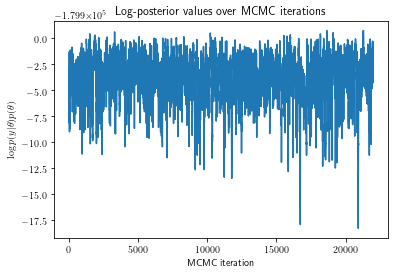

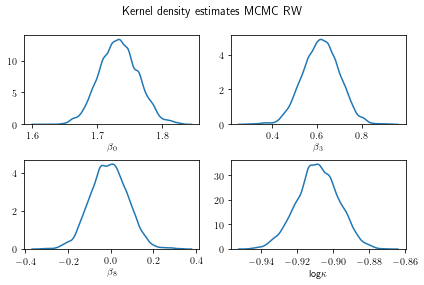

In [ ]:
# Provide your code in this cell
# Specify model
model = 'von Mises'
# Define the log-posterior
log_posterior = lambda theta: log_likelihood(theta, y, X, model) + log_prior(theta) 
obj_func_posterior = lambda theta: -log_posterior(theta) # For maximisation purpose
grad_obj_func_posterior = grad(obj_func_posterior) # Gradient of obj_func_posterior. Computed by automatic differentiation
Hess_obj_func_posterior  = hessian(obj_func_posterior) # Hessian of obj_func_posterior. Computed by automatic differentiation

# Find starting values by optimising the log-posterior
theta_optim_start = np.zeros(10)
res_optim_posterior = minimize(obj_func_posterior, theta_optim_start, method='BFGS', jac=grad_obj_func_posterior, options={'gtol': 1e-04, 'maxiter': 1000, 'disp': True})

# Compare answers
print('True parameter values')
print(theta0)
print('MAP estimates')
MAP = res_optim_posterior.x
print(np.round(MAP, 2))
thetaStar_von_Mises = MAP # Save for computing the control variate later
Sigma_pi_von_Mises = np.linalg.inv(Hess_obj_func_posterior(MAP)) # Negative Hessian inverse evaluated at the mode
PropCov = 2.38**2/d*Sigma_pi_von_Mises

# Ready for Metropolis-Hastings sampling
N = 22000 # MCMC samples

# Storage
theta_init = MAP + sps.norm.rvs(0, 0.01, len(MAP))
samples = np.zeros((N + 1, d))
samples[0, :] = theta_init
log_p_samples = np.zeros(N + 1)
log_p_samples[0] = log_posterior(theta_init)
alphas = np.zeros(N)

# Current parameter and evaluate quantities
theta_c = theta_init      
log_post_c = log_posterior(theta_c)

tic = time.time()
for i in range(1, N + 1):

    if i % 1000 == 0:
        print("Iteration i = {}. Acceptance prob (mean) {:.2f}. Time: {:.2f}".format(i , np.mean(alphas[:i]), time.time() - tic))

    # Propose parameter and evaluate quantities
    theta_p = np.random.multivariate_normal(theta_c, PropCov, size = 1).flatten() # flatten() to get 1-dim array 
    log_post_p = log_posterior(theta_p)
    log_q_p = sps.multivariate_normal.logpdf(theta_p, mean = theta_c, cov = PropCov) # log-proposal density. Symmetric (cancels), but leave for completeness           
    log_q_c = sps.multivariate_normal.logpdf(theta_c, mean = theta_p, cov = PropCov)   
    
    alpha = np.min([1, np.exp(log_post_p - log_q_p - (log_post_c - log_q_c))])
    alphas[i - 1] = alpha
    if np.random.rand() < alpha: # sample Unif(0, 1) to determine acceptance
        samples[i, :] = theta_p
        log_p_samples[i] = log_post_p 
        # Proposed becomes current in next iteration
        theta_c, log_post_c, log_q_c = theta_p, log_post_p, log_q_p
    else:
        samples[i, :] = theta_c 
        log_p_samples[i] = log_post_c 

matplotlib.rc('text', usetex = True)
fig, ax = plt.subplots()
ax.plot(log_p_samples)
ax.set(xlabel='MCMC iteration', ylabel= r'$\log p(y|\theta)p(\theta)$' , 
       title= 'Log-posterior values over MCMC iterations')

# Use 2000 as burn-in
samples = samples[2000:] 
samples_von_Mises_RW = samples # Save the samples from the random walk for future comparisons. 

# Effective sample size and inefficiency factors
ESS = np.zeros(samples.shape[1])
for j in range(samples.shape[1]):
    ESS[j] = effective_sample_size(samples[:, j])    
IF = samples.shape[0]/ESS
IF_MCMC_RW_von_Mises = IF # Save for comparing to subsampling MCMC later
   
print("Mean ESS: {:.2f}. Median ESS: {:.2f}. Min ESS: {:.2f}. Max ESS: {:.2f}".format(np.mean(ESS), np.median(ESS), np.min(ESS), np.max(ESS)))
print("Mean IF : {:.2f}. Median IF : {:.2f}. Min IF : {:.2f}. Max IF : {:.2f}".format(np.mean(IF), np.median(IF), np.min(IF), np.max(IF)))

# KDE estimates for selected four parameters (0, 1, ... , d - 1)
params_to_plot = [0, 3, 8, 9]
assert(len(params_to_plot) == 4)
if model == 'Poisson':
    param_names = [r'$\beta_%s$' % item for item in range(d)]
elif model == 'von Mises':
    param_names = [r'$\beta_%s$' % item for item in range(d-1)] + [r'log$\kappa$']
    
fig, axs = plt.subplots(2, 2)
fig.suptitle('Kernel density estimates MCMC RW')
k = 0
for i in range(2):
    for j in range(2):
        min_x = np.min(samples[:, params_to_plot[k]])
        max_x = np.max(samples[:, params_to_plot[k]])
        x_grid = np.linspace(min_x, max_x, 500)
        kde = sm.nonparametric.KDEUnivariate(samples[:, params_to_plot[k]]) # kernel density for each parameter
        kde.fit() 
        axs[i, j].plot(kde.support, kde.density)
        axs[i, j].set_ylim(ymin = 0)
        axs[i, j].set(xlabel = param_names[params_to_plot[k]])
        k = k + 1

fig.tight_layout()        
fig.subplots_adjust(top=0.88)
plt.show()

### 3.3 Beyond a random walk proposal
The random walk proposal is inefficient because it proposes locally rather than globally. The independence Metropolis-Hastings proposes globally using a multivariate Student-t proposal $$t_{\nu}(\boldsymbol{x} | \boldsymbol{\mu} , \boldsymbol{S}),$$
where $t$ denotes the multivariate t density with argument $\boldsymbol{x}$, degrees of freedom $\nu$, location $\boldsymbol{\mu}  = \boldsymbol{\theta}^\star$ and scale matrix $\boldsymbol{S} = \frac{\nu - 2}{\nu} \boldsymbol{\Sigma}_\pi$, with
\begin{eqnarray*}
\boldsymbol{\theta}^{\star} & = & \text{ the mode from a numerical optimization} \\
\boldsymbol{\Sigma_{\pi}}  & = & \text{ the posterior covariance } \quad (-\boldsymbol{\mathrm{H}}_{\boldsymbol{\theta}^{\star}}^{-1}).
\end{eqnarray*}

#### 3.3.1 Poisson regression model 
$\textbf{Exercise 3.3.1}$: Implement an independence Metropolis-Hastings algorithm for the Poisson regression model. Compare and comment on the inefficiency of the sampler compared to the random walk proposal. Compare the kernel density estimates. Provide the required code in the cell below. 

**Hint**: Requires minor modifications of the code using the random walk proposal. The functions *multivariate_t_rvs* and *multivariate_t_logpdf* defined in Section 1.3 will be useful.


         Current function value: 35737.403110
         Iterations: 23
         Function evaluations: 35
         Gradient evaluations: 34
True parameter values
[ 4.3   1.6  -1.06  0.77  2.37 -0.14 -0.81 -0.67  0.45  0.98]
MAP estimate
[ 4.3   1.59 -1.05  0.78  2.37 -0.13 -0.81 -0.67  0.44  0.99]
MCMC with independence proposal for the Poisson regression model with n = 10000
Iteration i = 1000. Acceptance prob (mean) 0.73. Time: 1.63
Iteration i = 2000. Acceptance prob (mean) 0.74. Time: 2.80
Iteration i = 3000. Acceptance prob (mean) 0.74. Time: 3.97
Iteration i = 4000. Acceptance prob (mean) 0.73. Time: 5.14
Iteration i = 5000. Acceptance prob (mean) 0.73. Time: 6.30
Iteration i = 6000. Acceptance prob (mean) 0.73. Time: 7.47
Iteration i = 7000. Acceptance prob (mean) 0.73. Time: 8.64
Iteration i = 8000. Acceptance prob (mean) 0.73. Time: 9.83
Iteration i = 9000. Acceptance prob (mean) 0.73. Time: 11.04
Iteration i = 10000. Acceptance prob (mean) 0.74. Time: 12.25
Iteration i = 11000.

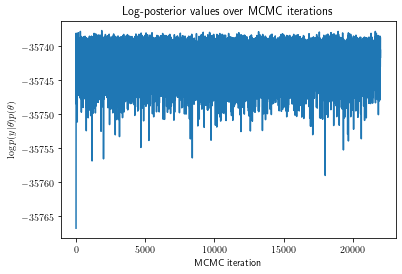

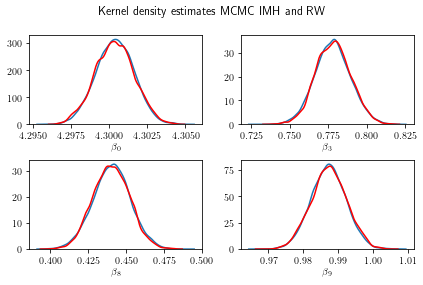

In [ ]:
# Provide your code in this cell
nu = 10 # Degrees of Freedom t-proposal
samples_RW = samples_Poisson_RW # plot the comparison. 

# Provide the code for the Metropolis-Hastings algorithm with an independence proposal for the Poisson regression model


# Specify model
model = 'Poisson'
# Define the log-posterior
log_posterior = lambda theta: log_likelihood(theta, y, X, model) + log_prior(theta) 
obj_func_posterior = lambda theta: -log_posterior(theta) # For maximisation purpose
grad_obj_func_posterior = grad(obj_func_posterior) # Gradient of obj_func_posterior. Computed by automatic differentiation
Hess_obj_func_posterior  = hessian(obj_func_posterior) # Hessian of obj_func_posterior. Computed by automatic differentiation

# Find starting values by optimising the log-posterior
theta_optim_start = np.zeros(10)
res_optim_posterior = minimize(obj_func_posterior, theta_optim_start, method='BFGS', jac=grad_obj_func_posterior, options={'gtol': 1e-04, 'maxiter': 1000, 'disp': True})

# Compare answers
print('True parameter values')
print(theta0)
print('MAP estimate')
MAP = res_optim_posterior.x
print(np.round(MAP, 2))
PropCov = np.linalg.inv(Hess_obj_func_posterior(MAP)) # Negative Hessian inverse evaluated at the mode
Scale =  ((nu - 2)/nu)*PropCov

# Ready for Metropolis-Hastings sampling
N = 22000 # MCMC samples

# Storage
theta_init = MAP + sps.norm.rvs(0, 0.01, len(MAP))
samples = np.zeros((N + 1, d))
samples[0, :] = theta_init
log_p_samples = np.zeros(N + 1)
log_p_samples[0] = log_posterior(theta_init)
alphas = np.zeros(N)

# Current parameter and evaluate quantities
theta_c = theta_init      
log_post_c = log_posterior(theta_c)

tic = time.time()
print('MCMC with independence proposal for the Poisson regression model with n = %s' % n)
for i in range(1, N + 1):

    if i % 1000 == 0:
        print("Iteration i = {}. Acceptance prob (mean) {:.2f}. Time: {:.2f}".format(i , np.mean(alphas[:i]), time.time() - tic))

    # Propose parameter and evaluate quantities
    theta_p =  multivariate_t_rvs(MAP, Scale, df = nu, n = 1).flatten()
    log_post_p = log_posterior(theta_p)
    log_q_p = multivariate_t_logpdf(theta_p, MAP, Scale, nu) # log-proposal density. Not symmetric!         
    log_q_c = multivariate_t_logpdf(theta_c, MAP, Scale, nu)
    
     
    
    alpha = np.min([1, np.exp(log_post_p - log_q_p - (log_post_c - log_q_c))])
    alphas[i - 1] = alpha
    if np.random.rand() < alpha: # sample Unif(0, 1) to determine acceptance
        samples[i, :] = theta_p
        log_p_samples[i] = log_post_p 
        # Proposed becomes current in next iteration
        theta_c, log_post_c, log_q_c = theta_p, log_post_p, log_q_p
    else:
        samples[i, :] = theta_c 
        log_p_samples[i] = log_post_c 

matplotlib.rc('text', usetex = True)
fig, ax = plt.subplots()
ax.plot(log_p_samples)
ax.set(xlabel='MCMC iteration', ylabel= r'$\log p(y|\theta)p(\theta)$' , 
       title= 'Log-posterior values over MCMC iterations')

# Use 2000 as burn-in
samples = samples[2000:] 

# Effective sample size and inefficiency factors
ESS = np.zeros(samples.shape[1])
for j in range(samples.shape[1]):
    ESS[j] = effective_sample_size(samples[:, j])    
IF = samples.shape[0]/ESS
   
print("Mean ESS: {:.2f}. Median ESS: {:.2f}. Min ESS: {:.2f}. Max ESS: {:.2f}".format(np.mean(ESS), np.median(ESS), np.min(ESS), np.max(ESS)))
print("Mean IF : {:.2f}. Median IF : {:.2f}. Min IF : {:.2f}. Max IF : {:.2f}".format(np.mean(IF), np.median(IF), np.min(IF), np.max(IF)))

# KDE estimates for selected four parameters (0, 1, ... , d - 1)
params_to_plot = [0, 3, 8, 9]
assert(len(params_to_plot) == 4)
if model == 'Poisson':
    param_names = [r'$\beta_%s$' % item for item in range(d)]
elif model == 'von Mises':
    param_names = [r'$\beta_%s$' % item for item in range(d-1)] + [r'$\log-\kappa_%s$']





# The following codes plots the kernel density estimates of the indepedence MH sampler (assuming they are stored in samples) 
# and the RW sampler (assuming they are stored in samples_RW)    
fig, axs = plt.subplots(2, 2)
fig.suptitle('Kernel density estimates MCMC IMH and RW')
k = 0
for i in range(2):
    for j in range(2):
        # Independence Metropolis-Hastings (IMH)
        min_x = np.min(samples[:, params_to_plot[k]])
        max_x = np.max(samples[:, params_to_plot[k]])
        x_grid = np.linspace(min_x, max_x, 500)
        kde = sm.nonparametric.KDEUnivariate(samples[:, params_to_plot[k]]) # kernel density for each parameter
        kde.fit() 
        axs[i, j].plot(kde.support, kde.density)
        
        # RW Metropolis-Hastings
        min_x = np.min(samples_RW[:, params_to_plot[k]])
        max_x = np.max(samples_RW[:, params_to_plot[k]])
        x_grid = np.linspace(min_x, max_x, 500)
        kde = sm.nonparametric.KDEUnivariate(samples_RW[:, params_to_plot[k]]) # kernel density for each parameter
        kde.fit() 
        axs[i, j].plot(kde.support, kde.density, color = 'red')
        axs[i, j].set_ylim(ymin = 0)
        axs[i, j].set(xlabel = param_names[params_to_plot[k]])
        k = k + 1

fig.tight_layout()        
fig.subplots_adjust(top=0.88)
plt.show()

#### 3.3.2 von Mises regression model 
$\textbf{Exercise 3.3.2}$: Repeat $\textbf{Exercise 3.3.1}$ for the von Mises regression model. Provide the required code in the cell below. 

Optimization terminated successfully.
         Current function value: 179898.715421
         Iterations: 26
         Function evaluations: 37
         Gradient evaluations: 37
True parameter values
[ 1.75        0.96       -1.3         0.52        0.64       -1.01
 -1.22        0.61        0.1        -0.91629073]
MAP estimate
[ 1.73  0.87 -1.26  0.62  0.65 -0.96 -1.16  0.62 -0.   -0.91]
MCMC with independence proposal for the von Mises regression model with n = 100000
Iteration i = 1000. Acceptance prob (mean) 0.72. Time: 1.50
Iteration i = 2000. Acceptance prob (mean) 0.71. Time: 2.95
Iteration i = 3000. Acceptance prob (mean) 0.71. Time: 4.41
Iteration i = 4000. Acceptance prob (mean) 0.71. Time: 5.85
Iteration i = 5000. Acceptance prob (mean) 0.72. Time: 7.28
Iteration i = 6000. Acceptance prob (mean) 0.72. Time: 8.70
Iteration i = 7000. Acceptance prob (mean) 0.72. Time: 10.15
Iteration i = 8000. Acceptance prob (mean) 0.72. Time: 11.60
Iteration i = 9000. Acceptance prob (mean) 0

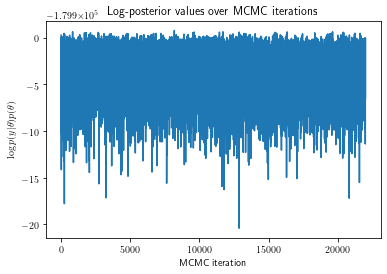

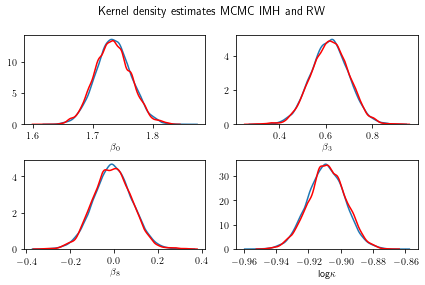

In [ ]:
# Provide your code in this cell
nu = 10 # Degrees of Freedom t-proposal
samples_RW = samples_von_Mises_RW # plot the comparison.

# Provide the code for the Metropolis-Hastings algorithm (including the plots for comparison) with an independence proposal for the 
# von Mises regression model 


# Specify model
model = 'von Mises'
# Define the log-posterior
log_posterior = lambda theta: log_likelihood(theta, y, X, model) + log_prior(theta) 
obj_func_posterior = lambda theta: -log_posterior(theta) # For maximisation purpose
grad_obj_func_posterior = grad(obj_func_posterior) # Gradient of obj_func_posterior. Computed by automatic differentiation
Hess_obj_func_posterior  = hessian(obj_func_posterior) # Hessian of obj_func_posterior. Computed by automatic differentiation

# Find starting values by optimising the log-posterior
theta_optim_start = np.zeros(10)
res_optim_posterior = minimize(obj_func_posterior, theta_optim_start, method='BFGS', jac=grad_obj_func_posterior, options={'gtol': 1e-04, 'maxiter': 1000, 'disp': True})

# Compare answers
print('True parameter values')
print(theta0)
print('MAP estimate')
MAP = res_optim_posterior.x
print(np.round(MAP, 2))
PropCov = np.linalg.inv(Hess_obj_func_posterior(MAP)) # Negative Hessian inverse evaluated at the mode
Scale =  ((nu - 2)/nu)*PropCov

# Ready for Metropolis-Hastings sampling
N = 22000 # MCMC samples

# Storage
theta_init = MAP + sps.norm.rvs(0, 0.01, len(MAP))
samples = np.zeros((N + 1, d))
samples[0, :] = theta_init
log_p_samples = np.zeros(N + 1)
log_p_samples[0] = log_posterior(theta_init)
alphas = np.zeros(N)

# Current parameter and evaluate quantities
theta_c = theta_init      
log_post_c = log_posterior(theta_c)

tic = time.time()
print('MCMC with independence proposal for the von Mises regression model with n = %s' % n)
for i in range(1, N + 1):

    if i % 1000 == 0:
        print("Iteration i = {}. Acceptance prob (mean) {:.2f}. Time: {:.2f}".format(i , np.mean(alphas[:i]), time.time() - tic))

    # Propose parameter and evaluate quantities
    theta_p =  multivariate_t_rvs(MAP, Scale, df = nu, n = 1).flatten()
    log_post_p = log_posterior(theta_p)
    log_q_p = multivariate_t_logpdf(theta_p, MAP, Scale, nu) # log-proposal density. Not symmetric!         
    log_q_c = multivariate_t_logpdf(theta_c, MAP, Scale, nu)
    
    alpha = np.min([1, np.exp(log_post_p - log_q_p - (log_post_c - log_q_c))])
    alphas[i - 1] = alpha
    if np.random.rand() < alpha: # sample Unif(0, 1) to determine acceptance
        samples[i, :] = theta_p
        log_p_samples[i] = log_post_p 
        # Proposed becomes current in next iteration
        theta_c, log_post_c, log_q_c = theta_p, log_post_p, log_q_p
    else:
        samples[i, :] = theta_c 
        log_p_samples[i] = log_post_c 

matplotlib.rc('text', usetex = True)
fig, ax = plt.subplots()
ax.plot(log_p_samples)
ax.set(xlabel='MCMC iteration', ylabel= r'$\log p(y|\theta)p(\theta)$' , 
       title= 'Log-posterior values over MCMC iterations')

# Use 2000 as burn-in
samples = samples[2000:] 

# Effective sample size and inefficiency factors
ESS = np.zeros(samples.shape[1])
for j in range(samples.shape[1]):
    ESS[j] = effective_sample_size(samples[:, j])    
IF = samples.shape[0]/ESS
   
print("Mean ESS: {:.2f}. Median ESS: {:.2f}. Min ESS: {:.2f}. Max ESS: {:.2f}".format(np.mean(ESS), np.median(ESS), np.min(ESS), np.max(ESS)))
print("Mean IF : {:.2f}. Median IF : {:.2f}. Min IF : {:.2f}. Max IF : {:.2f}".format(np.mean(IF), np.median(IF), np.min(IF), np.max(IF)))

# KDE estimates for selected four parameters (0, 1, ... , d - 1)
params_to_plot = [0, 3, 8, 9]
assert(len(params_to_plot) == 4)
if model == 'Poisson':
    param_names = [r'$\beta_%s$' % item for item in range(d)]
elif model == 'von Mises':
    param_names = [r'$\beta_%s$' % item for item in range(d-1)] + [r'log$\kappa$']

# The following codes plots the kernel density estimates of the indepedence MH sampler (assuming they are stored in samples) 
# and the RW sampler (assuming they are stored in samples_RW)    
fig, axs = plt.subplots(2, 2)
fig.suptitle('Kernel density estimates MCMC IMH and RW')
k = 0
for i in range(2):
    for j in range(2):
        # Independence Metropolis-Hastings (IMH)
        min_x = np.min(samples[:, params_to_plot[k]])
        max_x = np.max(samples[:, params_to_plot[k]])
        x_grid = np.linspace(min_x, max_x, 500)
        kde = sm.nonparametric.KDEUnivariate(samples[:, params_to_plot[k]]) # kernel density for each parameter
        kde.fit() 
        axs[i, j].plot(kde.support, kde.density)
        
        # RW Metropolis-Hastings
        min_x = np.min(samples_RW[:, params_to_plot[k]])
        max_x = np.max(samples_RW[:, params_to_plot[k]])
        x_grid = np.linspace(min_x, max_x, 500)
        kde = sm.nonparametric.KDEUnivariate(samples_RW[:, params_to_plot[k]]) # kernel density for each parameter
        kde.fit() 
        axs[i, j].plot(kde.support, kde.density, color = 'red')
        axs[i, j].set_ylim(ymin = 0)
        axs[i, j].set(xlabel = param_names[params_to_plot[k]])
        k = k + 1

fig.tight_layout()        
fig.subplots_adjust(top=0.88)
plt.show()

## 4. Parameter expanded control variates
We now construct parameter expanded control variates for the two models above. **Note that this assumes that we have specified both log-densities correctly**. The following code computes the log density, its gradient and its Hessian for *all observations in the dataset*. This is needed to construct the control variates. This is a time consuming operation, which luckily only needs to be done once for a given dataset. Ideally, we would run this code in a parallel computing environment.

In [ ]:
def initiate_control_variate_quantities(log_density, y, X, thetaStar):
    """
    Creates the quantities needed to construct the second order parameter expanded Taylor control variates for the log_density.
    Output from this function will go into the function eval_q_k
    """
    n = len(y)
    p = len(thetaStar)

    dens_at_thetaStar = log_density(thetaStar, y, X)
    grad_at_thetaStar = np.zeros([n, p])
    Hess_at_thetaStar = np.zeros([n, p, p])
    grad_dens = grad(log_density, 0)
    Hess_dens = hessian(log_density, 0)
    
    for i in range(n):    
        if i % 1000 == 0:
            print("Processed %s observations (out of % s)" % (i, n))
        grad_at_thetaStar[i, :], Hess_at_thetaStar[i, :] = grad_dens(thetaStar, y[i], X[i]), Hess_dens(thetaStar, y[i], X[i])
                    
    return dens_at_thetaStar, grad_at_thetaStar, Hess_at_thetaStar

**Note that the below code only initiates the Poisson model regression control variates.**

In [ ]:
thetaStar = thetaStar_Poisson
dens_at_thetaStar_Poisson, grad_at_thetaStar_Poisson, Hess_at_thetaStar_Poisson = initiate_control_variate_quantities(log_density_Poisson, y, X, thetaStar)

NameError: name 'thetaStar_Poisson' is not defined

The following function evaluates the control variates for the observations. 

In [ ]:
def eval_q_k(theta, dens_at_thetaStar, grad_at_thetaStar, Hess_at_thetaStar, order = 2):
    """
    Evaluates the order order parameter expanded Taylor control variates at the point theta for all observations in 
    dens_at_thetaStar, grad_at_thetaStar, Hess_at_thetaStar. Default order is 2.
    """
    const_term = dens_at_thetaStar
    if order == 0:
        q_k = const_term
    elif order == 1:
        first_term = np.sum(grad_at_thetaStar*(theta - thetaStar), axis = 1)
        q_k = const_term + first_term
    elif order == 2:
        first_term = np.sum(grad_at_thetaStar*(theta - thetaStar), axis = 1)
        second_term = 0.5*np.sum(np.sum(Hess_at_thetaStar*np.outer(theta - thetaStar, theta - thetaStar), axis = 1), axis = 1)    
        q_k = const_term + first_term + second_term
    else:
        raise ValueError("Order must be 0 <= order <= 2")
    return q_k

## 4.1 Evaluating the control variates for the Poisson regression model
We now construct control variates for the Poisson regression model and evaluate their accuracy. The following code constructs the control variates with different orders (0, 1, 2) of the Taylor approximation. The control variates are evaluated using one (several if you rerun a few times) sample $\boldsymbol{\theta}$ from the normal approximation of the posterior distribution.

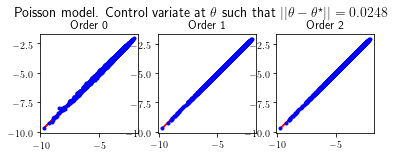

In [ ]:
dens_at_thetaStar, grad_at_thetaStar, Hess_at_thetaStar = dens_at_thetaStar_Poisson, grad_at_thetaStar_Poisson, Hess_at_thetaStar_Poisson
theta = np.random.multivariate_normal(thetaStar, Sigma_pi_Poisson, size = 1).flatten()
q_k_order0 = eval_q_k(theta, dens_at_thetaStar, grad_at_thetaStar, Hess_at_thetaStar, order = 0) 
q_k_order1 = eval_q_k(theta, dens_at_thetaStar, grad_at_thetaStar, Hess_at_thetaStar, order = 1) 
q_k_order2 = eval_q_k(theta, dens_at_thetaStar, grad_at_thetaStar, Hess_at_thetaStar, order = 2) 
l_k = log_density_Poisson(theta, y, X)
fig, axs = plt.subplots(1, 3)
fig.suptitle(r'Poisson model. Control variate at $\theta$ such that $||\theta - \theta^\star|| = %3.4f$' % np.linalg.norm(theta - thetaStar), size = 14)
for k in range(3):
        axs[k].plot(l_k, l_k, color = 'red')
        if k == 0:
            axs[k].plot(l_k, q_k_order0, '.', color = 'blue')
            axs[k].set_title('Order 0', size = 12)
        elif k == 1:
            axs[k].plot(l_k, q_k_order1, '.', color = 'blue')
            axs[k].set_title('Order 1', size = 12)
        elif k == 2:
            axs[k].plot(l_k, q_k_order2, '.', color = 'blue')
            axs[k].set_title('Order 2', size = 12)
            
        axs[k].axis('scaled')

fig.subplots_adjust(top=1.3)
plt.show()

## 4.2 Evaluating the control variates for the von Mises regression model
$\textbf{Exercise 4.2}$: Repeat $\textbf{Exercise 4.1}$ for the von Mises regression model. First run the initialise control variate procedure in the cell below and then provide the required code for this exercise two cells below

In [ ]:
thetaStar = thetaStar_von_Mises # Assumes thetaStar_von_Mises has been saved
dens_at_thetaStar_von_Mises, grad_at_thetaStar_von_Mises, Hess_at_thetaStar_von_Mises = initiate_control_variate_quantities(log_density_von_Mises, y, X, thetaStar)

In [ ]:
# Provide your code in this cell


## 5. Approximate subsampling MCMC
We are now ready to implement the approximate subsampling MCMC algorithm. 

### 5.1 Subsampling MCMC for the Poisson regression model
The following is an almost complete code for performing subsampling MCMC for the Poisson regression model using a random walk proposal. The default values are set to $m=100$ (subsample size), $G=10$ (number of blocks) and Taylor order $2$.

$\textbf{Exercise 5.1}$: Complete the code in the cell below **marked by TODO**. Try different orders for the Taylor approximation when running the code.

In [ ]:
# Modify the code below the TODO
# Specify model
model = 'Poisson'
if model == 'Poisson':
    log_density = log_density_Poisson
    dens_at_thetaStar, grad_at_thetaStar, Hess_at_thetaStar = dens_at_thetaStar_Poisson, grad_at_thetaStar_Poisson, Hess_at_thetaStar_Poisson
    thetaStar = thetaStar_Poisson # Control variate expanded around this
    samples_RW = samples_Poisson_RW
elif model == 'von Mises':
    dens_at_thetaStar, grad_at_thetaStar, Hess_at_thetaStar = dens_at_thetaStar_von_Mises, grad_at_thetaStar_von_Mises, Hess_at_thetaStar_von_Mises
    thetaStar = thetaStar_von_Mises # Control variate expanded around this
    log_density = log_density_von_Mises
    samples_RW = samples_von_Mises_RW
else:
    raise NotImplementedError

# Define the log-posterior
log_posterior = lambda theta: log_likelihood(theta, y, X, model) + log_prior(theta) 
obj_func_posterior = lambda theta: -log_posterior(theta) # For maximisation purpose
grad_obj_func_posterior = grad(obj_func_posterior) # Gradient of obj_func_posterior. Computed by automatic differentiation
Hess_obj_func_posterior  = hessian(obj_func_posterior) # Hessian of obj_func_posterior. Computed by automatic differentiation

# Find starting values by optimising the log-posterior
theta_optim_start = np.zeros(10)
res_optim_posterior = minimize(obj_func_posterior, theta_optim_start, method='BFGS', jac=grad_obj_func_posterior, options={'gtol': 1e-04, 'maxiter': 1000, 'disp': True})

# Compare answers
print('True parameter values')
print(theta0)
print('MAP estimates')
MAP = res_optim_posterior.x
print(np.round(MAP, 2))

# Proposal covariance
Sigma_pi = np.linalg.inv(Hess_obj_func_posterior(MAP)) # Negative Hessian inverse evaluated at the mode
PropCov = 2.38**2/d*Sigma_pi

# Get ready for pseudo marginal Metropolis-Hastings sampling
Taylor_order = 2
N = 22000 # MCMC samples
G = 10 # Number of blocks
m = 100 # Subsample size
u_c = np.random.randint(0, n, m) 
u_block_indicators = np.hstack((np.repeat(np.arange(G-1), m/G), np.repeat(G-1, m - len(np.repeat(np.arange(G-1), m/G))))) # Splits the u into blocks

# Precomputed quantities for the control variates that do not depend on theta
# Following the notation in the slides
A = np.sum(dens_at_thetaStar) 
B = np.sum(grad_at_thetaStar, axis = 0)
C = np.sum(Hess_at_thetaStar, axis = 0)

if Taylor_order == 0:
    q_sum = lambda theta: A
elif Taylor_order == 1:
    q_sum = lambda theta: A + np.dot(B, theta - thetaStar)
elif Taylor_order == 2:
    q_sum = lambda theta: A + np.dot(B, theta - thetaStar) + 0.5*np.dot(theta - thetaStar, np.dot(C, theta - thetaStar))
else:
    raise NotImplementedError

# Storage
theta_init = MAP + sps.norm.rvs(0, 0.01, len(MAP))
samples = np.zeros((N + 1, d))
samples[0, :] = theta_init
alphas = np.zeros(N)
log_posthat_samples = np.zeros(N + 1) # Keeps the estimated value of the log-posterior (up to a normalisation constant)
sigma2_lhat_samples = np.zeros(N + 1) # Keeps the estimated variance of the log-likelihood estimator 

# Current parameter and evaluate quantities
theta_c = theta_init   
l_k_c = log_density(theta_c, y[u_c], X[u_c])  # log-densities at current theta, u
q_k_c = eval_q_k(theta_c, dens_at_thetaStar[u_c], grad_at_thetaStar[u_c], Hess_at_thetaStar[u_c], order = Taylor_order)  # control variates at current theta, u
log_posthat_c = q_sum(theta_c) + n*np.mean(l_k_c - q_k_c) + log_prior(theta_c)
sigma2_lhat_c = n**2/m*np.var(l_k_c - q_k_c, ddof = 1)
log_posthat_samples[0] = log_posthat_c
sigma2_lhat_samples[0] = sigma2_lhat_c

# Check
print('Estimate')
print(q_sum(theta_c) +  n*np.mean(l_k_c - q_k_c))
print('True value')
print(log_likelihood(theta_c, y, X, model))

tic = time.time()
print('Subsampling MCMC for the Poisson regression model with n = %s, m = %s, G = %s and Taylor order = %s' % (n, m, G, Taylor_order))
for i in range(1, N + 1):

    if i % 1000 == 0:
        print("Iteration i = {}. Acceptance prob (mean) {:.2f}. Time: {:.2f}".format(i , np.mean(alphas[:i]), time.time() - tic))

    # Propose parameter vector and subsample
    theta_p = np.random.multivariate_normal(theta_c, PropCov, size = 1).flatten() # flatten() to get 1-dim array 
    
    block_to_update = np.random.randint(0, G, 1)[0]
    u_p = copy.copy(u_c)
    indices_to_update = (u_block_indicators == block_to_update)
    u_p[indices_to_update] = np.random.randint(0, n, np.sum(indices_to_update)) 
    
    # TODO: 
    # 1. Evaluate log densities and control variates at theta_p, u_p. 
    # 2. Estimate the log-likelihood and the variance of the log-likelihood
    l_k_p = '?' # '?' # Your code instead of '?' # log-densities at proposed theta, u
    q_k_p = '?' # '?' # Your code instead of '?'  # control variates at proposed theta, u
    log_posthat_p = '?' # '?' # Your code instead of '?' # log-likelihood estimator at proposed theta, u
    sigma2_lhat_p = '?' # '?' # Your code instead of '?' # estimate of variance of log-likelihood estimator at proposed theta, u
    
    # log proposal densities
    log_q_p = sps.multivariate_normal.logpdf(theta_p, mean = theta_c, cov = PropCov) # log-proposal density. Symmetric (cancels), but leave for completeness           
    log_q_c = sps.multivariate_normal.logpdf(theta_c, mean = theta_p, cov = PropCov)   
    
    alpha = np.min([1, np.exp(log_posthat_p - sigma2_lhat_p/2 - log_q_p - (log_posthat_c - sigma2_lhat_c/2 - log_q_c))])
    alphas[i - 1] = alpha
    if np.random.rand() < alpha: # sample Unif(0, 1) to determine acceptance
        samples[i, :] = theta_p
        log_posthat_samples[i] = log_post_p 
        sigma2_lhat_samples[i] = sigma2_lhat_p
        # Proposed becomes current in next iteration
        theta_c, log_posthat_c, sigma2_lhat_c, log_q_c, u_c = theta_p, log_posthat_p, sigma2_lhat_p, log_q_p, u_p
    else:
        samples[i, :] = theta_c 
        log_posthat_samples[i] = log_posthat_c 
        sigma2_lhat_samples[i] = sigma2_lhat_c
        

matplotlib.rc('text', usetex = True)
fig, ax = plt.subplots()
ax.plot(log_posthat_samples)
ax.set(xlabel='MCMC iteration', ylabel= r'Estimated $log p(y|\theta)p(\theta)$' , 
       title= 'Estimated log-posterior values over MCMC iterations')

fig, ax = plt.subplots()
ax.plot(sigma2_lhat_samples, color = 'red')
ax.set(xlabel='MCMC iteration', ylabel= r'Estimated $\sigma^2_{\widehat{d}}(\theta)$' , 
       title= 'Estimated variance of log-likelihood estimator over MCMC iterations')
ax.set_yscale('log')

# Use 2000 as burn-in
samples = samples[2000:] 

# Effective sample size and inefficiency factors
ESS = np.zeros(samples.shape[1])
for j in range(samples.shape[1]):
    ESS[j] = effective_sample_size(samples[:, j])    
IF = samples.shape[0]/ESS
   
print("Mean ESS: {:.2f}. Median ESS: {:.2f}. Min ESS: {:.2f}. Max ESS: {:.2f}".format(np.mean(ESS), np.median(ESS), np.min(ESS), np.max(ESS)))
print("Mean IF : {:.2f}. Median IF : {:.2f}. Min IF : {:.2f}. Max IF : {:.2f}".format(np.mean(IF), np.median(IF), np.min(IF), np.max(IF)))
RCT = (n*IF_MCMC_RW_Poisson)/(m*IF)
print("RCT (vs full data) : {:.2f}. Median RCT : {:.2f}. Min RCT : {:.2f}. Max RCT : {:.2f}".format(np.mean(RCT), np.median(RCT), np.min(RCT), np.max(RCT)))

# KDE estimates for selected four parameters (0, 1, ... , d - 1)
params_to_plot = [0, 3, 8, 9]
assert(len(params_to_plot) == 4)
if model == 'Poisson':
    param_names = [r'$\beta_%s$' % item for item in range(d)]
elif model == 'von Mises':
    param_names = [r'$\beta_%s$' % item for item in range(d-1)] + [r'log$\kappa$']
    

# The following codes plots the kernel density estimates of the subsampling MCMC(assuming they are stored in samples) 
# and the RW sampler (assuming they are stored in samples_RW)    
fig, axs = plt.subplots(2, 2)
fig.suptitle('Kernel density estimates subsampling MCMC (blue) and MCMC (purple) IMH and RW')
k = 0
for i in range(2):
    for j in range(2):
        # Subsampling MCMC with a RW
        min_x = np.min(samples[:, params_to_plot[k]])
        max_x = np.max(samples[:, params_to_plot[k]])
        x_grid = np.linspace(min_x, max_x, 500)
        kde = sm.nonparametric.KDEUnivariate(samples[:, params_to_plot[k]]) # kernel density for each parameter
        kde.fit() 
        axs[i, j].plot(kde.support, kde.density)
        
        # RW Metropolis-Hastings (Full data)
        min_x = np.min(samples_RW[:, params_to_plot[k]])
        max_x = np.max(samples_RW[:, params_to_plot[k]])
        x_grid = np.linspace(min_x, max_x, 500)
        kde = sm.nonparametric.KDEUnivariate(samples_RW[:, params_to_plot[k]]) # kernel density for each parameter
        kde.fit() 
        axs[i, j].plot(kde.support, kde.density, color = 'purple')
        axs[i, j].set_ylim(ymin = 0)
        axs[i, j].set(xlabel = param_names[params_to_plot[k]])
        k = k + 1

fig.tight_layout()        
fig.subplots_adjust(top=0.88)
plt.show()        

NameError: name 'dens_at_thetaStar_Poisson' is not defined

### 5.2 Subsampling MCMC for the von Mises regression model
$\textbf{Exercise 5.2}$: Implement a subsampling MCMC algorithm to sample from the posterior of the von Mises regression model using a random walk proposal. Compare your results against the corresponding full data Metropolis-Hastings sampler. Provide the required code in the cell below.



In [ ]:
# Provide your code in this cell


### 5.3 Subsampling MCMC using an independence Metropolis-Hastings model (<span style="color:red">optional and extra</span>)
$\textbf{Exercise 5.3}$: For your choice of model above (the Poisson regression model or the von Mises regression model), implement a subsampling MCMC algorithm to sample from the posterior using an independence Metropolis-Hastings proposal following Section 3.3. Compare your results against the corresponding full data Metropolis-Hastings sampler. Provide the required code in the cell below.


In [ ]:
# Provide your code in this cell


This concludes the computer lab and also the course. I hope you enjoyed it!